Date: 24/2/2026

# Neural network for detecting credit card fraud from scratch

The task at hand is to create a 'simple' neural network with backpropagation 'from scratch' for our dataset of choice. Our chosen dataset is in this directory under card_transdata.csv. We already have made a thorough analysis which can be viewed in fraud.ipynb. The main takeaways are the following points:

* There are 7 features in total with 3 continuous features and 4 binary features.
* The 3 continuous features follow a powerlaw-distribution.
* There is a ~9:1 class inbalance for negative instances

Not only are we to set up, train and validate the neural network, we are also to investigate the research question: 
    
**How do varying degrees of label class imbalance affect training and performance of a neural network?**

This research question guides us to take a closer look at what is happening in the training stage and collect data on this so we can compare this data to the data collected from training the model on a slightly altered dataset with a different ratio of class imbalance.

Let's first start by splitting up our datasets. Our plain dataset has an approximate 9:91 (actually 8.74) split. 
For now, we will make two other datasets with the approximate splits: 4:96 and 14:86, but we may need more with different ratios, so we will write a general function for any split

To get the desired ratios we over- or undersample from the negative samples. We don't touch the positive samples because there are too few of them.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

# seed for randomness. Set manually for reproducability.
RANDOM_SEED = int(time.time_ns() % (2**32))
np.random.seed(RANDOM_SEED)

# load data
data = np.loadtxt('./card_transdata.csv', delimiter=',')

# take log of continuous features
data[:, 0:3] = np.log1p(data[:, 0:3])

# standardize continuous features with mean = 0 and var = 1
means = data[:, 0:3].mean(axis=0)
stds = data[:, 0:3].std(axis=0)

data[:, 0:3] = (data[:, 0:3] - means) / stds

# Split positive and negative instances
pos = data[data[:, 7] == 1]
neg = data[data[:, 7] == 0]

n_pos = len(pos)
n_neg = len(neg)

print(n_pos)
print(n_neg)

# general function for any ratio
def create_dataset_with_ratio(positives, negatives, target_ratio):
    
    P = len(positives)
    N = len(negatives)
    original_ratio = P / (P + N)
    
    if target_ratio > original_ratio:
        # Target has MORE positives than original → undersample negatives
        N_new = int((P / target_ratio) - P)
        if N_new <= 0:
            raise ValueError("Target ratio too large.")
        selected_negatives = negatives[np.random.choice(N, size=N_new, replace=False)]
        selected_positives = positives

    else:
        # Target has FEWER positives than original → undersample positives
        P_new = int(target_ratio * N / (1 - target_ratio))
        if P_new <= 0:
            raise ValueError("Target ratio too small.")
        selected_positives = positives[np.random.choice(P, size=P_new, replace=False)]
        selected_negatives = negatives

    new_data = np.vstack((selected_positives, selected_negatives))
    np.random.shuffle(new_data)
    
    return new_data

# More imbalanced (~3.74% positive)
data_3_74 = create_dataset_with_ratio(pos, neg, 0.0374)

# Less imbalanced (~13.74% positive)
data_13_74 = create_dataset_with_ratio(pos, neg, 0.1374)

87403
912597


We now have three datasets. Lets put them in an array so we can loop over them. If we so desire, we can make a range of different datasets. This would be very, very memory intesive though.

We are almost done with preprocessing. We also have to split into train/validate/test and seperate out the labels.

In [10]:
all_sets = [data, data_3_74, data_13_74]
sets_with_split = []

def split_class(class_data):
    n = len(class_data)
    one_third = n // 3
    
    train = class_data[:one_third]
    val   = class_data[one_third:2*one_third]
    test  = class_data[2*one_third:]
    
    return train, val, test

# HYPERPARAMETER: train/validate/test split ratio. For now, I will do 1:1:1 split.
for data_set in all_sets:
    # Separate by class
    positives = data_set[data_set[:, 7] == 1]
    negatives = data_set[data_set[:, 7] == 0]
    
    # Shuffle each class separately
    np.random.shuffle(positives)
    np.random.shuffle(negatives)
    
    # Split classes
    pos_train, pos_val, pos_test = split_class(positives)
    neg_train, neg_val, neg_test = split_class(negatives)
    
    # Combine classes back together
    train = np.vstack((pos_train, neg_train))
    val   = np.vstack((pos_val,   neg_val))
    test  = np.vstack((pos_test,  neg_test))
    
    # Shuffle final sets
    np.random.shuffle(train)
    np.random.shuffle(val)
    np.random.shuffle(test)
    
    sets_with_split.append({
        'train': train,
        'val': val,
        'test': test
    })

for i, dataset_splits in enumerate(sets_with_split):
    print(f"\nDataset {i}:")
    print(f"  Train: {dataset_splits['train'].shape}")
    print(f"  Val:   {dataset_splits['val'].shape}")
    print(f"  Test:  {dataset_splits['test'].shape}")


Dataset 0:
  Train: (333333, 8)
  Val:   (333333, 8)
  Test:  (333334, 8)

Dataset 1:
  Train: (316018, 8)
  Val:   (316018, 8)
  Test:  (316018, 8)

Dataset 2:
  Train: (212039, 8)
  Val:   (212039, 8)
  Test:  (212042, 8)


The sizes of the sets have changed significantly. Especially the dataset with an even larger class inbalance is huge (more than doubled). This might be indication that we ought to change our approach to changing the class inbalance ratio as we now have a lot of redundancy in that dataset which may lead to overfitting. We could also test both methods: oversampling the negatives or undersampling the positives.

We now have our data prepared and our ducks in a row. We can start building the neural net.

The backpropagation algorithm goes, as specified in the slides, in the following steps:

* Do a forward pass.
* Start at the top (output) of your computation graph. (and store all intermediate values)
* Compute (and store) the derivative of every node.
* Work your way down (?). I assume this means perform gradient descent on the weights in the model after finding the gradient.

It is going to be harder to seperate the code snippets with markdown explanations from this point on. But I will try.

While writing the code, we came across an important consideration which we hadn't thought of before: the initialization strategy. Some research revealed something called the **Xavier/Glorot initialization**(we can use this for citing) strategy which is just initializing randomly from a normal distribution with mean=0 and variance=(some function over the number of input nodes and the number of output nodes). We also learned that initializing the biases with 0 is generally ok.

Another thing we came across was the problem of vanishing or exploding gradients. However, since we are only doing one hidden layer, this shouldn't become a problem

The next code block initializes the model weights and biases

In [11]:
# another hyper parameter I will change the code at some point to put all the hyperparamers in one spot so we can easily tune them
N_hidden_nodes = 15
# we only do one hidden layer so no hyper parameter for that

model_weights =[]

# initialize weights for three models using the xavier/glorot initialization strategy
for i in range(0, 3):
    
    # Initialize weights for input -> hidden layer (input layer has a fixed size: 7)
    limit_1 = np.sqrt(6 / (7 + N_hidden_nodes))
    W1 = np.random.uniform(-limit_1, limit_1, (N_hidden_nodes, 7))
    b1 = np.zeros(N_hidden_nodes)
    
    # Initialize weights for hidden -> output layer (output layer has a fixed size: 1)
    limit_2 = np.sqrt(6 / (N_hidden_nodes + 1))
    W2 = np.random.uniform(-limit_2, limit_2, N_hidden_nodes)
    b2 = 0
    
    weights = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }
    
    model_weights.append(weights)

print(len(model_weights))


3


We now have the initial weights set. I believe that from this point on, we can completely perform the backprop algorithm. Lets start with a forward pass.

Another consideration is how we make the algorithm terminate. For now I will just let it run four epochs. At some point, we may want to make it terminate conditionally based on how much or how little the loss changes.

In [12]:
# hyperparameters
from IPython.display import display

epochs = 15
learning_rate = 0.005
BATCH_SIZE = 64  # minibatch size hyperparameter (set to 1 for stochastic, or len(train) for full batch)

# code for plotting the loss
loss_histories = [[], [], []]

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(x, weights):
    # x      : (B, 7)
    # W1     : (N_hidden, 7)  ->  k = x @ W1.T + b1  shape (B, N_hidden)
    k = x @ weights['W1'].T + weights['b1']          # (B, N_hidden)
    h = sigmoid(k)                                    # (B, N_hidden)
    # W2     : (N_hidden,)    ->  y = h @ W2 + b2    shape (B,)
    y = h @ weights['W2'] + weights['b2']             # (B,)
    y_sig = sigmoid(y)                                # (B,)
    return k, h, y, y_sig

def backward(x, h, y_sig, t, weights):
    B = x.shape[0]

    # d_y  : (B,)  –  dL/dy (combined BCE + sigmoid derivative)
    d_y = y_sig - t                                   # (B,)

    # gradients for output layer
    d_w2 = (h * d_y[:, None]).mean(axis=0)           # (N_hidden,)
    d_b2 = d_y.mean()                                 # scalar

    # back-propagate through hidden sigmoid
    d_h  = d_y[:, None] * weights['W2']              # (B, N_hidden)
    d_k  = d_h * h * (1.0 - h)                       # (B, N_hidden)

    # gradients for hidden layer
    d_w1 = (d_k[:, :, None] * x[:, None, :]).mean(axis=0)  # (N_hidden, 7)
    d_b1 = d_k.mean(axis=0)                          # (N_hidden,)

    return d_w1, d_b1, d_w2, d_b2

# train for all ratios iteratively
for dataset_idx, (data_set, weights) in enumerate(zip(sets_with_split, model_weights)):
    train_data = data_set['train']
    N = len(train_data)

    for epoch in range(epochs):
        # Shuffle training data at the start of each epoch
        idx = np.random.permutation(N)
        train_shuffled = train_data[idx]

        n_batches = int(np.ceil(N / BATCH_SIZE))

        for batch_num in range(n_batches):

            if batch_num % 500 == 0:
                print(f'Dataset {dataset_idx} | Epoch {epoch} | Batch {batch_num}/{n_batches}')
            
            start = batch_num * BATCH_SIZE
            end   = min(start + BATCH_SIZE, N) # Since you take the min, you can't get an out of bounds
            batch = train_shuffled[start:end]

            x = batch[:, :7]   # (B, 7)
            t = batch[:, 7]    # (B,)

            # --- forward ---
            k, h, y, y_sig = forward(x, weights)

            # --- batch BCE loss (mean over batch) ---
            eps = 1e-12  # numerical stability
            loss = -np.mean(t * np.log(y_sig + eps) + (1.0 - t) * np.log(1.0 - y_sig + eps))
            loss_histories[dataset_idx].append(loss)

            # --- backward ---
            d_w1, d_b1, d_w2, d_b2 = backward(x, h, y_sig, t, weights)

            # --- gradient descent update ---
            weights['W1'] -= learning_rate * d_w1
            weights['b1'] -= learning_rate * d_b1
            weights['W2'] -= learning_rate * d_w2
            weights['b2'] -= learning_rate * d_b2

            
            

Dataset 0 | Epoch 0 | Batch 0/5209
Dataset 0 | Epoch 0 | Batch 500/5209
Dataset 0 | Epoch 0 | Batch 1000/5209
Dataset 0 | Epoch 0 | Batch 1500/5209
Dataset 0 | Epoch 0 | Batch 2000/5209
Dataset 0 | Epoch 0 | Batch 2500/5209
Dataset 0 | Epoch 0 | Batch 3000/5209
Dataset 0 | Epoch 0 | Batch 3500/5209
Dataset 0 | Epoch 0 | Batch 4000/5209
Dataset 0 | Epoch 0 | Batch 4500/5209
Dataset 0 | Epoch 0 | Batch 5000/5209
Dataset 0 | Epoch 1 | Batch 0/5209
Dataset 0 | Epoch 1 | Batch 500/5209
Dataset 0 | Epoch 1 | Batch 1000/5209
Dataset 0 | Epoch 1 | Batch 1500/5209
Dataset 0 | Epoch 1 | Batch 2000/5209
Dataset 0 | Epoch 1 | Batch 2500/5209
Dataset 0 | Epoch 1 | Batch 3000/5209
Dataset 0 | Epoch 1 | Batch 3500/5209
Dataset 0 | Epoch 1 | Batch 4000/5209
Dataset 0 | Epoch 1 | Batch 4500/5209
Dataset 0 | Epoch 1 | Batch 5000/5209
Dataset 0 | Epoch 2 | Batch 0/5209
Dataset 0 | Epoch 2 | Batch 500/5209
Dataset 0 | Epoch 2 | Batch 1000/5209
Dataset 0 | Epoch 2 | Batch 1500/5209
Dataset 0 | Epoch 2 | Ba

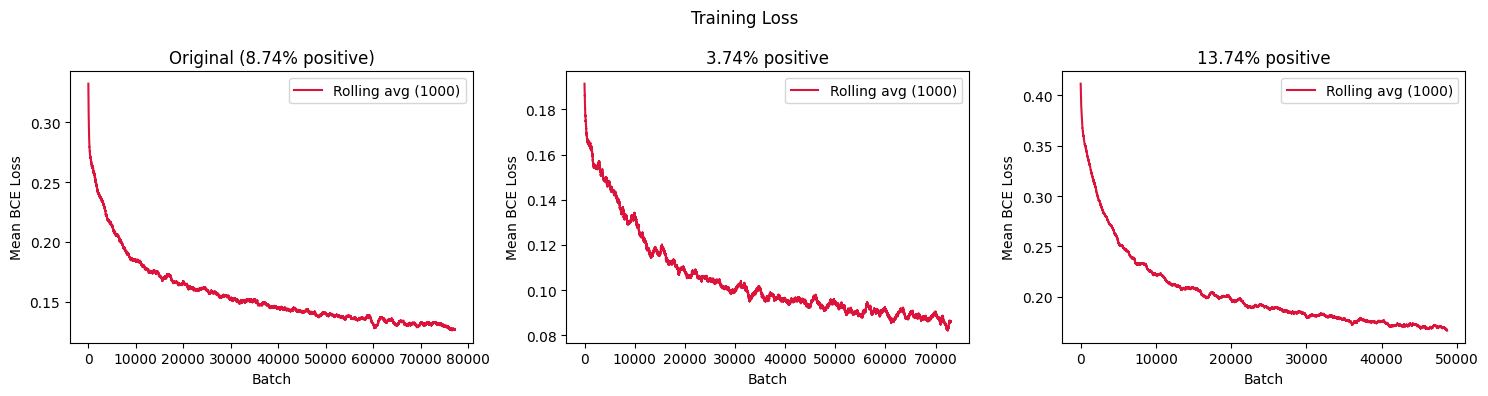

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Original (8.74% positive)', '3.74% positive', '13.74% positive']

for idx, (ax, history, label) in enumerate(zip(axes, loss_histories, labels)):
    #ax.plot(history, linewidth=0.5, alpha=0.4, color='steelblue', label='Raw loss')
    
    # rolling average to see trend through the noise
    window = 1000
    if len(history) >= window:
        rolling = np.convolve(history, np.ones(window)/window, mode='valid')
        ax.plot(rolling, linewidth=1.5, color='crimson', label=f'Rolling avg ({window})')
    
    ax.set_title(label)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Mean BCE Loss')
    ax.legend()

fig.suptitle('Training Loss')
plt.tight_layout()
plt.show()


It is 10/03

I implemented the vectorization of the linear operations in the forward and the backwards pass.
I implemented the minibatch gradient descent. The current batch size is 64.

These two changes drastically reduced training time: it went from hours for just 2 epochs to less than a minute for 15 epochs.

I changed the strategy for getting a lower ratio of positive classes. It now undersamples the positive class.

I seperated the forward, backward and sigmoid into functions, this will help with validating and testing.

Some notes on the loss results: It learns like crazy :). But the loss seems to correlate with lower ratio to lower loss which is not that weird, but to properly evaluate the models, we need to compute the ROC and AUC.

So next up is evaluating the models!

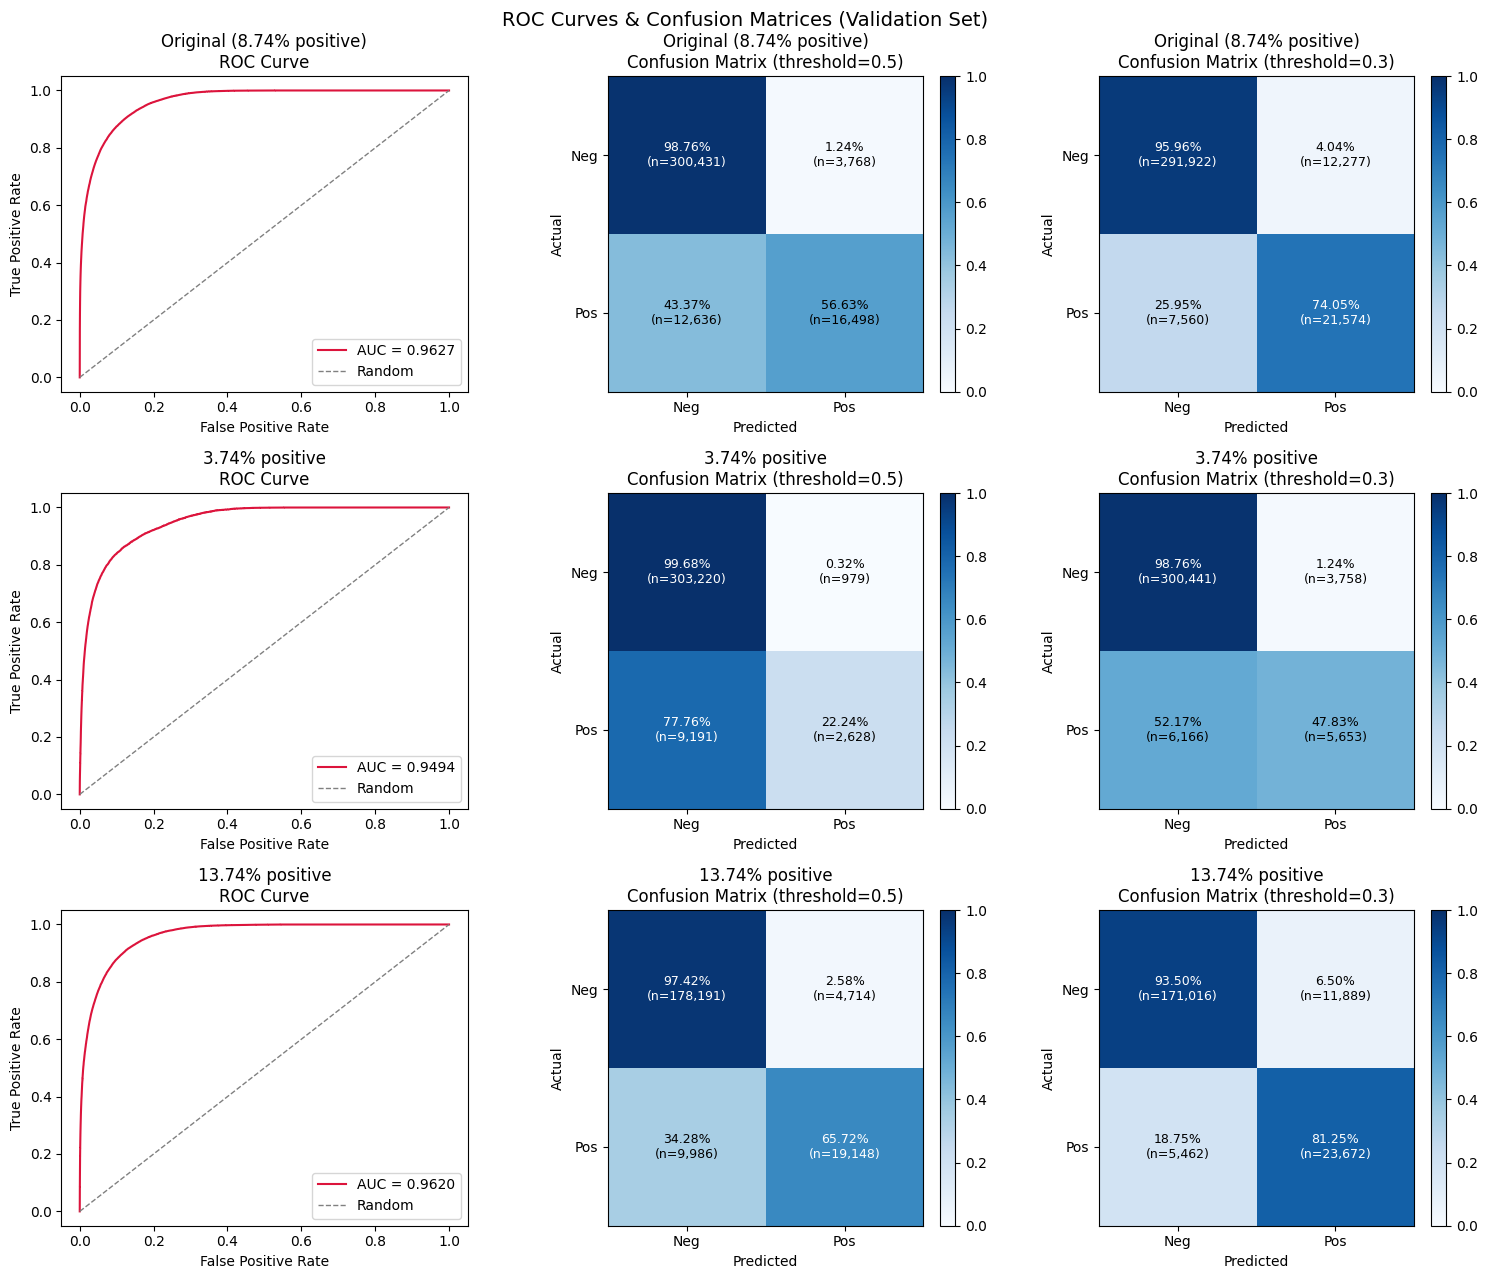

In [21]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
labels = ['Original (8.74% positive)', '3.74% positive', '13.74% positive']

for idx, (data_set, weights, label) in enumerate(zip(sets_with_split, model_weights, labels)):

    val_data = data_set['val']
    x_val = val_data[:, :7]
    t_val = val_data[:, 7]

    # Forward pass on the full validation set
    _, _, _, y_sig = forward(x_val, weights)

    # --- ROC + AUC ---
    fpr, tpr, thresholds = roc_curve(t_val, y_sig)
    roc_auc = auc(fpr, tpr)

    ax_roc = axes[idx, 0]
    ax_roc.plot(fpr, tpr, color='crimson', linewidth=1.5, label=f'AUC = {roc_auc:.4f}')
    ax_roc.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random')
    ax_roc.set_title(f'{label}\nROC Curve')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()

    # --- Confusion matrix at threshold = 0.5 ---
    for col_idx, threshold in enumerate([0.5, 0.3], start=1):
        y_pred = (y_sig >= threshold).astype(int)
        cm = confusion_matrix(t_val, y_pred)

        # Normalise rows so each cell shows recall per class
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax_cm = axes[idx, col_idx]
        im = ax_cm.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

        # Annotate: normalised rate (top) + raw count (bottom)
        for i in range(2):
            for j in range(2):
                ax_cm.text(j, i,
                    f'{cm_norm[i, j]:.2%}\n(n={cm[i, j]:,})',
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_norm[i, j] > 0.6 else 'black')

        ax_cm.set_title(f'{label}\nConfusion Matrix (threshold={threshold})')
        ax_cm.set_xlabel('Predicted')
        ax_cm.set_ylabel('Actual')
        ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(['Neg', 'Pos'])
        ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(['Neg', 'Pos'])

        # Colourbar
        plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

fig.suptitle('ROC Curves & Confusion Matrices (Validation Set)', fontsize=14)
plt.tight_layout()
plt.show()